In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load all tables
orders    = pd.read_csv('../data/raw/olist_orders_dataset.csv')
items     = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
products  = pd.read_csv('../data/raw/olist_products_dataset.csv')
sellers   = pd.read_csv('../data/raw/olist_sellers_dataset.csv')
reviews   = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
payments  = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
category  = pd.read_csv('../data/raw/product_category_name_translation.csv')

print("✓ All tables loaded")
for name, df in [("orders",orders),("items",items),("customers",customers),
                 ("products",products),("sellers",sellers),
                 ("reviews",reviews),("payments",payments),("category",category)]:
    print(f"  {name}: {len(df):,} rows, {df.shape[1]} columns")

✓ All tables loaded
  orders: 99,441 rows, 8 columns
  items: 112,650 rows, 7 columns
  customers: 99,441 rows, 5 columns
  products: 32,951 rows, 9 columns
  sellers: 3,095 rows, 4 columns
  reviews: 99,224 rows, 7 columns
  payments: 103,886 rows, 5 columns
  category: 71 rows, 2 columns


In [5]:
print(f"category: {len(category):,} rows, {category.shape[1]} columns")
print(category.head())

category: 71 rows, 2 columns
    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor


In [7]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

print("Date range:")
print(f"  From: {orders['order_purchase_timestamp'].min().date()}")
print(f"  To:   {orders['order_purchase_timestamp'].max().date()}")
print(f"\nOrder status breakdown:")
print(orders['order_status'].value_counts())

Date range:
  From: 2016-09-04
  To:   2018-10-17

Order status breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [8]:
# Merge items → products → category translation
merged = items.merge(products[['product_id','product_category_name']], on='product_id')
merged = merged.merge(category, left_on='product_category_name', 
                      right_on='product_category_name', how='left')

revenue = (merged.groupby('product_category_name_english')['price']
           .sum()
           .sort_values(ascending=False)
           .head(10)
           .reset_index())
revenue.columns = ['category', 'revenue']
revenue['revenue'] = revenue['revenue'].round(2)
print(revenue)

                category     revenue
0          health_beauty  1258681.34
1          watches_gifts  1205005.68
2         bed_bath_table  1036988.68
3         sports_leisure   988048.97
4  computers_accessories   911954.32
5        furniture_decor   729762.49
6             cool_stuff   635290.85
7             housewares   632248.66
8                   auto   592720.11
9           garden_tools   485256.46


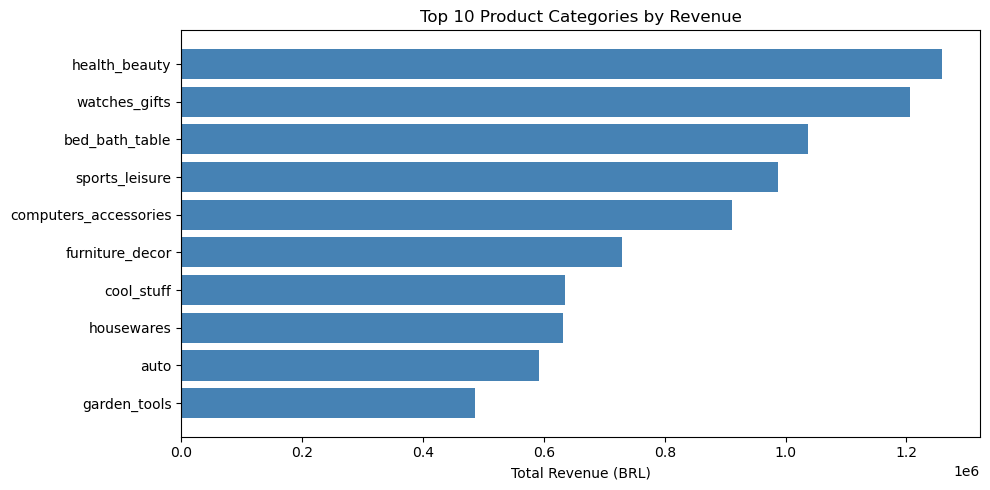

✓ Chart saved to data/exports/


In [13]:
plt.figure(figsize=(10, 5))
plt.barh(revenue['category'][::-1], revenue['revenue'][::-1], color='steelblue')
plt.xlabel('Total Revenue (BRL)')
plt.title('Top 10 Product Categories by Revenue')
plt.tight_layout()
plt.savefig('../data/exports/top_categories.png', dpi=150)
plt.show()
print("✓ Chart saved to data/exports/")

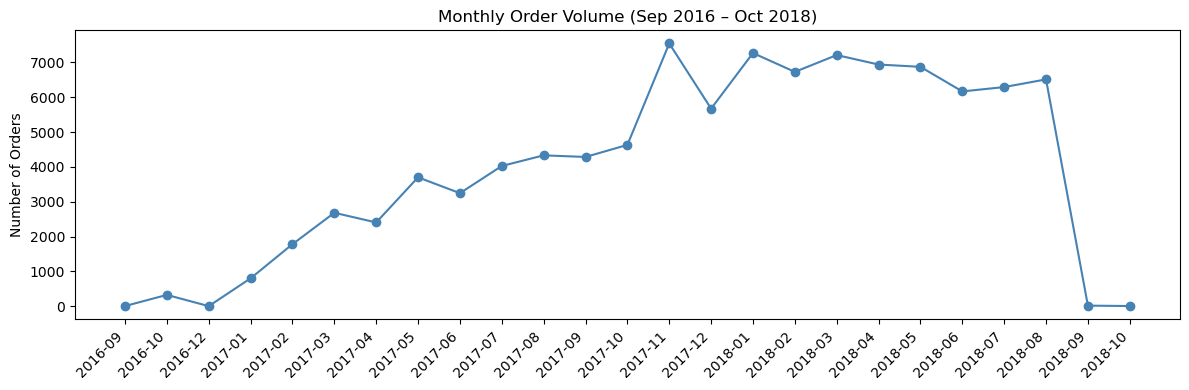

✓ Saved


In [14]:
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly = orders.groupby('month').size().reset_index(name='order_count')
monthly['month_str'] = monthly['month'].astype(str)

plt.figure(figsize=(12, 4))
plt.plot(monthly['month_str'], monthly['order_count'], marker='o', color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Order Volume (Sep 2016 – Oct 2018)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('../data/exports/monthly_trend.png', dpi=150)
plt.show()
print("✓ Saved")

In [15]:
merged_reviews = orders.merge(reviews[['order_id','review_score']], on='order_id')
merged_reviews = merged_reviews.merge(items[['order_id','product_id']], on='order_id')
merged_reviews = merged_reviews.merge(products[['product_id','product_category_name']], on='product_id')
merged_reviews = merged_reviews.merge(category, on='product_category_name', how='left')

cat_scores = (merged_reviews.groupby('product_category_name_english')['review_score']
              .mean().sort_values(ascending=False).head(10).round(2))
print("Top 10 categories by avg review score:")
print(cat_scores)

Top 10 categories by avg review score:
product_category_name_english
cds_dvds_musicals                        4.64
fashion_childrens_clothes                4.50
books_general_interest                   4.45
costruction_tools_tools                  4.44
flowers                                  4.42
books_imported                           4.40
books_technical                          4.37
food_drink                               4.32
luggage_accessories                      4.32
small_appliances_home_oven_and_coffee    4.30
Name: review_score, dtype: float64
